In [24]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv(r'C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\movies.csv')
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


In [44]:
print(df.shape)
print(df.isnull().sum())

(9568, 9)
movies         0
year        9568
genre          0
rating         0
one-line       0
stars          0
votes          0
runtime        0
gross          0
dtype: int64


In [26]:
df.shape

(9999, 9)

In [27]:
df = df.drop_duplicates()

In [28]:
# Standardizing column names 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [29]:
# Replace placeholder values with NaN
df.replace(['?', 'NA', 'N/A', 'na', ''], np.nan, inplace=True)

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\2726342143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace(['?', 'NA', 'N/A', 'na', ''], np.nan, inplace=True)


In [30]:
# Convert numeric-like columns
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\3560759604.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col])


In [43]:
print(df.shape)
print(df.isnull().sum())

(9568, 9)
movies         0
year        9568
genre          0
rating         0
one-line       0
stars          0
votes          0
runtime        0
gross          0
dtype: int64


In [31]:
# Separate numeric & categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [32]:
# Fill numeric missing values with median
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\3831978160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))


In [33]:
# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\2454913545.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


In [34]:
df

,movies,year,genre,rating,one-line,stars,votes,runtime,gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,$0.01M
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,$0.01M
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,$0.01M
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,$0.01M
4,Army of Thieves,(2021),"\nAction, Crime, Horror",7.1,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,7,60.0,$0.01M
...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,(2022– ),"\nDrama, Thriller",7.1,\nAdd a Plot\n,\n Director:\nNicolai Rohde\n| \n Stars:...,7,60.0,$0.01M
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",7.1,\nAdd a Plot\n,\n,7,60.0,$0.01M
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",7.1,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,7,60.0,$0.01M
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",7.1,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,7,60.0,$0.01M


# EDA

In [35]:
df.dtypes

movies       object
year         object
genre        object
rating      float64
one-line     object
stars        object
votes        object
runtime     float64
gross        object
dtype: object

In [36]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\191729642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = pd.to_numeric(df['year'], errors='coerce')


In [37]:
df['gross'] = (
    df['gross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('M', 'e6', regex=False)
    .str.replace('K', 'e3', regex=False)
)

df['gross'] = pd.to_numeric(df['gross'], errors='coerce')

C:\Users\adity\AppData\Local\Temp\ipykernel_40012\3047768455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gross'] = (
C:\Users\adity\AppData\Local\Temp\ipykernel_40012\3047768455.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gross'] = pd.to_numeric(df['gross'], errors='coerce')


In [38]:
df.dtypes

movies       object
year        float64
genre        object
rating      float64
one-line     object
stars        object
votes        object
runtime     float64
gross       float64
dtype: object

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


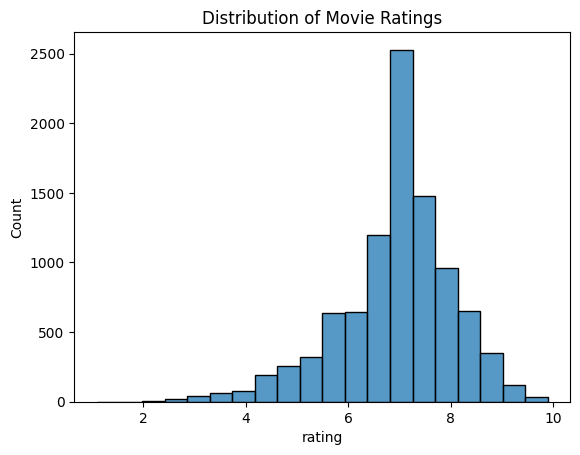

In [39]:
# Rating Distribution
plt.figure()
sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.show()

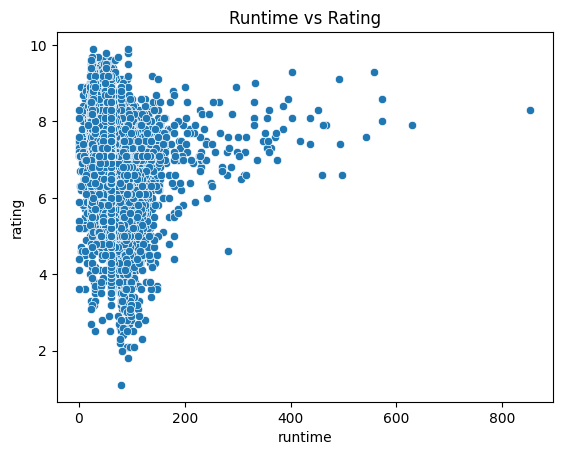

In [ ]:
# Runtime vs Rating 
plt.figure()
sns.scatterplot(x='runtime', y='rating', data=df)
plt.title("Runtime vs Rating")
plt.show()

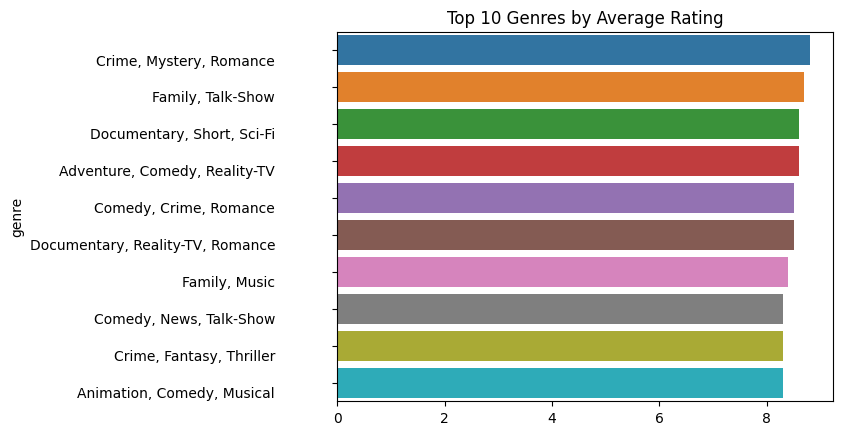

In [ ]:
# Top 10 Genres by Average Rating
top_genre = (
    df.groupby('genre')['rating'].mean().sort_values(ascending=False).head(10)
)

plt.figure()
sns.barplot(x=top_genre.values, y=top_genre.index)
plt.title("Top 10 Genres by Average Rating")
plt.show()

In [ ]:
df

,movies,year,genre,rating,one-line,stars,votes,runtime,gross
0,Blood Red Sky,NaN,"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,10000.0
1,Masters of the Universe: Revelation,NaN,"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,10000.0
2,The Walking Dead,NaN,"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,10000.0
3,Rick and Morty,NaN,"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,10000.0
4,Army of Thieves,NaN,"\nAction, Crime, Horror",7.1,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,7,60.0,10000.0
...,...,...,...,...,...,...,...,...,...
9993,Totenfrau,NaN,"\nDrama, Thriller",7.1,\nAdd a Plot\n,\n Director:\nNicolai Rohde\n| \n Stars:...,7,60.0,10000.0
9995,Arcane,NaN,"\nAnimation, Action, Adventure",7.1,\nAdd a Plot\n,\n,7,60.0,10000.0
9996,Heart of Invictus,NaN,"\nDocumentary, Sport",7.1,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,7,60.0,10000.0
9997,The Imperfects,NaN,"\nAdventure, Drama, Fantasy",7.1,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,7,60.0,10000.0


# 1. Find the movies with the highest profit

In [42]:


# create profit column
df["profit"] = df["gross"] - df["budget"]

# highest profit movies
top_profit = df[["movie_title","profit"]].dropna().sort_values(by="profit", ascending=False)

print(top_profit.head(10))

KeyError: 'budget'